---
format:
  html:
    code-fold: true
execute:
  echo: true
---

[← Back to article notes](../index.qmd)

# Implementation notebook

- Title: A deep learning method for solving Fokker-Planck equations
- Authors: Li, Dobson, Zhai
- Year:    2022

In [20]:
#| code-summary: "Import Libraries"
import torch
import operator
from tqdm.notebook import tqdm
from typing import Tuple, Callable, Any
from torch.func import vmap, jacrev, hessian
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader
from functools import reduce

In [21]:
#| code-summary: "Fake Numerical Method"
class NumericalMethod:
    def __init__(
        self,
        grid_shape: Tuple[int,...],  # shape of the grid: (d1,...,dN)
        box: Tuple[Tuple[float, float],...],  # ranges for each axis: ((a1,b1),...,(aN,bN))
        u_sol_prop: Callable[[torch.Tensor], torch.Tensor],  # ideal solution
        noise_scale: float,  # positive value
    ):
        self.box = torch.tensor(box)
        self.grid_shape = torch.tensor(grid_shape)
        # points[i] is a tensor with shape (size,) and values in box_i0, box_i1
        points = tuple(torch.linspace(box[i][0], box[i][1], size) for i, size in enumerate(grid_shape))
        # points[i] begins a tensor with shape grid_shape and points[i][a1,a2,...] <- points[i][ai]
        points = torch.meshgrid(*points, indexing='ij')
        # convert tuple to tensor, so the current shape is (grid_shape,N)
        points = torch.stack(tuple(tt for tt in points), axis=-1)
        self.points = points
        
        # compute ideal values
        # points[i] begins a tensor with shape (N,) and points[i] <- points[j_1,...,j_N] using a map i -> j(1),...,j(N)
        points = points.reshape(-1,points.shape[-1])
        # values is a tensor with shape (M,)
        values = u_sol_prop(points)
        # values begins a tensor with shape grid_shape
        values = values.reshape(grid_shape)
        # normalization
        volume = reduce(operator.mul, tuple(boxi[1]-boxi[0] for boxi in box), 1)
        values = values / (torch.mean(values) * volume)
        
        # now, noisy map is a map of normalized gaussian noise
        little_volume = volume / values.numel()
        noisy_map = torch.randn(*(size for size in grid_shape))
        b_variance = values * little_volume * (1 - values * little_volume)
        noisy_map = noisy_map * noise_scale * b_variance.sqrt()
        
        # add noise
        self.values = values + noisy_map
        self.values = torch.clamp(self.values, min=0)
        # normalize again (with sum=1)
        self.values = self.values / (torch.mean(self.values) * volume)
        self.noisy_map = self.values - values

    def __call__(self, x: torch.Tensor):
        # x has shape (batch_size, N)
        
        # find indices
        c = (self.box[:,1]-self.box[:,0]) / self.grid_shape
        i = ((x - self.box[:,0][None,:])/c[None,:]).long()
        
        # clamp indices
        for k, s in enumerate(self.grid_shape):
            i[:,k] = torch.clamp(i[:,k], 0, s-1)
        
        # ravel i
        ravel_i = torch.zeros(i.shape[0],dtype=torch.long)
        for k, s in enumerate(self.grid_shape):
            ravel_i = ravel_i * s + i[:,k]
        return self.values.flatten()[ravel_i]
    
hx, hy = 200, 200
r = 2.0
c = 1.0
u_infty = lambda x: torch.exp(-2*(torch.sum(x**2, dim=-1)-1)**2)
method = NumericalMethod(
    (hx,hy),
    ((-r,r),(-r,r)),
    u_infty,
    noise_scale=c
)

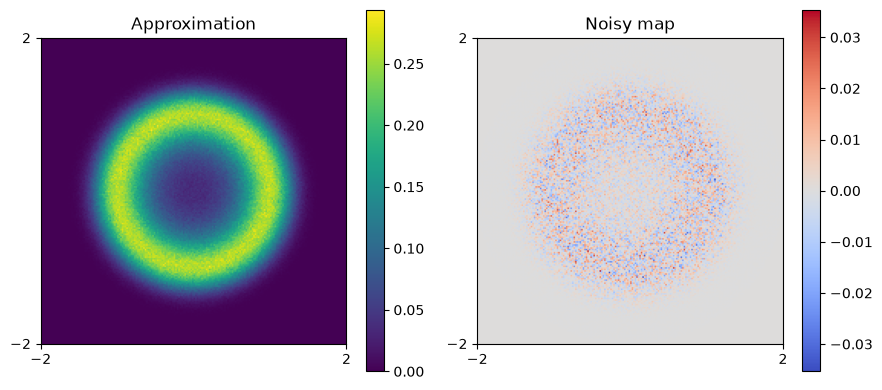

In [22]:
#| code-summary: "Just an example"
from matplotlib import pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
extent = [-r, r, -r, r]
im0 = axes[0].imshow(
    method.values,
    cmap="viridis",
    extent=extent,
    vmin=0,
    aspect="equal"
)
axes[0].set_title("Approximation")
fig.colorbar(im0, ax=axes[0])
m = method.noisy_map.abs().max()
im1 = axes[1].imshow(
    method.noisy_map,
    vmin=-m,
    vmax=m,
    cmap="coolwarm",
    extent=extent,
    origin="lower",
    aspect="equal"
)
axes[1].set_title("Noisy map")
for ax in axes:
    ax.set_xticks([-r,r])
    ax.set_yticks([-r,r])
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

In [23]:
#| code-summary: "Differential Calculus utilities"
from torch.func import vmap, jacrev, hessian

""" NOTE
for the followings functions "model" has the followins properties:
  * if the input's shape of the callable model is (batch, K)
      then the output's shape will be (batch, n1, ..., nm)
  * if the input's shape of the callable model is (K,)
      then the output will be (n1, ..., nm)
"""

def compute_jacobian(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor):
    # model image shape (batch, n1, ..., nm)
    # x shape (batch, k)
    # J shape (batch, n1, ..., nm, k)
    J = vmap(jacrev(model), randomness='same')(x)
    return J

def compute_hessian(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor):
    # model image shape (batch, n1, ..., nm)
    # x shape (batch, k)
    # H shape (batch, n1, ..., nm, k, k)
    H = vmap(hessian(model), randomness='same')(x)
    return H

def compute_laplacian(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor):
    # model image shape (batch, n1, ..., nm)
    # x shape (batch, k)
    # L shape (batch, n1, ..., nm)
    H = compute_hessian(model, x)
    laplacian = H.diagonal(dim1=-2, dim2=-1).sum(-1)
    return laplacian

def compute_divergence(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor):
    # model image shape (batch, n1, ..., n(m-1), k)
    # x shape (batch, k)
    # L shape (batch, n1, ..., n(m-1))
    J = compute_jacobian(model, x)
    divergence = J.diagonal(dim1=-2, dim2=-1).sum(-1)
    return divergence

## Loss Function
Let $\tilde{u}(x,\theta)$ be an approximation of $u$ that is represented by an artificial neural network with parameter $\theta$.

$$
    L(\theta) = \frac{1}{N^X}\sum_{i=1}^{N^X}(\mathcal{L}\tilde{u}(x_i,\theta))^2 + \frac{1}{N^Y}\sum_{j=1}^{N^Y}(\tilde{u}(y_j,\theta)-v(y_j))^2 := L_1(\theta)+L_2(\theta)
$$

where:

$$
    \mathcal{L}u = -\sum_{i=1}^n (f_i u)_{x_i} + \frac12\sum_{i,j}^n (\Sigma_{i,k}u)_{x_i,x_j} = \nabla_x\cdot\left(-fu+\frac12\nabla_x\cdot(\Sigma u)\right)
$$

### The General Equilibrium State
In order to obtain the following steady state $$ u_\infty(x) = \exp\left(- \frac{2 V(x)}{\sigma^2}\right) $$
we require the model defined by $\Sigma = \sigma^2\text{Id}$, $f = -\nabla_x V$

So:
$$
    \mathcal{L}u=-\nabla_x\cdot\left(fu\right)+\frac{\sigma^2}{2}\Delta_x^2 u = -\left(\nabla_x\cdot f\right)u - f\cdot \nabla_x u + \frac{\sigma^2}{2}\Delta_x^2 u
$$

#### 2D Ring Problem
Here, we use $V(x)=(\|x\|^2-1)^2$ and $\sigma = 1$, so the model is defined by $f = -4(\|x\|^2-1)x$.

We observe that $\nabla_x\cdot f = 4n-4(n+2)\|x\|^2$ and so
$$
    \mathcal{L}u = \left(4(n+2)\|x\|^2-4n\right)u + \left(4(\|x\|^2-1)x\right)\cdot \nabla_x u + \frac12\Delta_x^2 u
$$

In [24]:
#| code-summary: "Definition of the Loss Function"
def L_operator(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor):
    u = model(x)
    du = compute_jacobian(model, x)
    lu = compute_laplacian(model,x)
    
    n = x.shape[1]
    a1 = 4*(n+2)*torch.sum(x**2, dim=-1) - 4*n
    a2 = 4*(torch.sum(x**2, dim=-1, keepdim=True)-1)*x
    return u * a1 + torch.einsum('bi,bi->b',a2,du) + 0.5*lu

def loss_function_1(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor):
    return torch.mean(L_operator(model, x)**2)

def loss_function_2(model: Callable[[torch.Tensor], torch.Tensor], y: torch.Tensor, v: NumericalMethod):
    return torch.mean((model(y) - v(y))**2)

def loss_function(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, y: torch.Tensor, v: NumericalMethod):
    L1 = loss_function_1(model, x)
    L2 = loss_function_2(model, y, v)
    return L1 + L2, L1, L2

# !Test!
print(f"max residual = {L_operator(u_infty, torch.randn(1000,2)*2).max()}")

max residual = 1.430511474609375e-06


## Training Algorithm

Let $\mathcal{X}$ and $\mathcal{D}$ be the training and reference sets respectively.

The training uses mini-batch technique to compute the optimal parameter $\theta$.

### Dataloader

The reference set follows the solution distribution, we use the rejection sampling technique to emulate this process.

In [25]:
#|  code-summary: "Reference points dataloader"
class ReferenceLoader:
    def __init__(
        self,
        f: Callable[[torch.Tensor], torch.Tensor],
        M: float,
        d: int
    ):
        self.f = f
        self.M = M
        self.d = d

    def g(self, x: torch.Tensor):
        # x has shape (n_batch, dimension)
        return 1/(2*torch.pi)**(self.d/2) * torch.exp(-0.5*torch.sum(x**2, dim=-1))

    def __call__(self, N: int):
        X = torch.empty(N, self.d)
        counter = 0
        while counter < N:
            n = N - counter
            Xproposed = torch.randn(n, self.d)
            U = torch.rand(n) * self.M
            W = self.f(Xproposed) / self.g(Xproposed)
            Xproposed = Xproposed[W >= U]
            if Xproposed.shape[0] > 0:
                next_counter = counter + Xproposed.shape[0]
                X[counter:next_counter] = Xproposed
                counter = next_counter
        return X

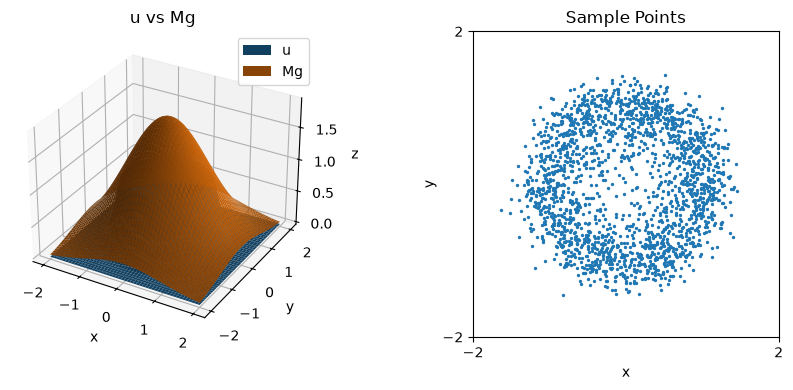

In [26]:
#| code-summary: "Just an example"
from matplotlib import pyplot as plt

# plot of the density function f
DsetLoader = ReferenceLoader(u_infty, M=12.0, d=2)
D = DsetLoader(2000)

# plot u_infty vs Mg as two surfaces in the same 3Dplot
x = torch.linspace(-2,2,200)
y = torch.linspace(-2,2,200)
x,y = torch.meshgrid(x,y, indexing='ij')
xy = torch.stack((x,y), dim=-1)
xy = xy.reshape(-1,2)
z1 = u_infty(xy).reshape(200,200)
z2 = DsetLoader.M * DsetLoader.g(xy).reshape(200,200)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.clf()
ax0 = fig.add_subplot(121, projection='3d')
ax0.plot_surface(x, y, z1, alpha=1.0)
ax0.plot_surface(x, y, z2, alpha=1.0)
ax0.set_xlabel('x')
ax0.set_ylabel('y')
ax0.set_zlabel('z')
ax0.legend(['u', 'Mg'])
ax0.set_title('u vs Mg')

ax1 = fig.add_subplot(122)
ax1.scatter(D[:,0], D[:,1], alpha=1.0, s=2)
ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_xticks([-r,r])
ax1.set_yticks([-r,r])
ax1.set_aspect('equal', adjustable='box')
ax1.set_title('Sample Points')
plt.tight_layout()
plt.show()


In [27]:
#| code-summary: "Mixed Dataloader"
DsetLoader = ReferenceLoader(u_infty, M=12.0, d=2)
def algorithm_2(alpha: float, Nx: int):
    X = DsetLoader(Nx)
    mask = torch.rand(X.shape[0]) > alpha
    X[mask] = torch.rand_like(X[mask]) * (2*r) - r
    return X

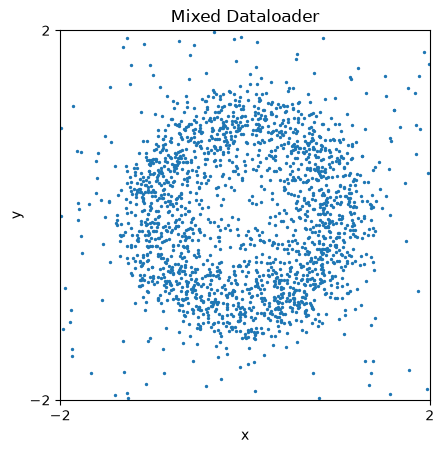

In [28]:
#| code-summary: "Just an example"
from matplotlib import pyplot as plt

X = algorithm_2(0.9, 2000)

plt.scatter(X[:, 0], X[:, 1], alpha=1.0, s=2)
plt.xlim(-r, r)
plt.ylim(-r, r)
plt.xlabel('x')
plt.ylabel('y')
plt.xticks([-r, r])
plt.yticks([-r, r])
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Mixed Dataloader')
plt.show()

In [29]:
#| code-summary: "Training loop"
def algorithm_1(model, alphax, Nx, alphad, Nd, n_batches, n_epochs):
    # model is a neural network
    # n_epochs is the number of iterations of the training loop
    
    # make the dataset
    X = algorithm_2(alphax, Nx*n_batches)
    D = algorithm_2(alphad, Nd*n_batches)
    
    # optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # training loop
    l1_list, l2_list, loss_list = [], [], []
    for epoch in tqdm(range(n_epochs), leave=False):
        # shuffle the datasets
        X = X[torch.randperm(len(X))]
        D = D[torch.randperm(len(D))]
        
        for i in tqdm(range(n_batches), leave=False):
            # get batches
            Xbatch = X[i*Nx:(i+1)*Nx]
            Ybatch = D[i*Nd:(i+1)*Nd]
            
            # l1 update
            optimizer.zero_grad()
            l1 = loss_function_1(model, Xbatch)
            l1.backward()
            optimizer.step()
            
            # l2 update
            optimizer.zero_grad()
            l2 = loss_function_2(model, Ybatch, method)
            l2.backward()
            optimizer.step()
            
            # save result
            l1_list.append(l1.item())
            l2_list.append(l2.item())
            loss = l1.item() + l2.item()
            loss_list.append(loss)
    
    return l1_list, l2_list, loss_list

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

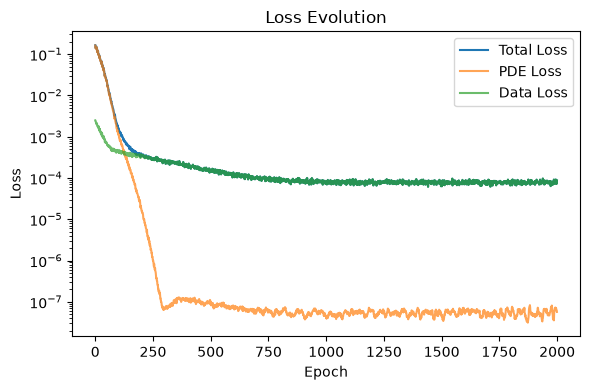

In [30]:
#| code-summary: "Just an example"
from matplotlib import pyplot as plt

"""
    In this example we have an ideal model:
        A * exp(-B*(||x||^2-C)^2)
    where A>0, B>0, C>0 are the parameters to be learned.
"""
theta_theory = torch.tensor([1.85458654213, 1.0, -1.3101303577423096])
class SimpleModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = torch.nn.Parameter(torch.randn(3)*0.1 + theta_theory)

    def forward(self, x):
        theta1, theta2, theta3 = self.theta
        return torch.exp(-F.softplus(theta1) * (torch.sum(x**2, dim=-1) - theta2**2)**2 + theta3)

# model
model = SimpleModel()

# training
l1_list, l2_list, loss_list = algorithm_1(model, 0.8, 256, 0.8, 512, 200, 10) 

# plot evolution of the losses
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_list, label='Total Loss')
ax.plot(l1_list, label='PDE Loss', alpha=0.7)
ax.plot(l2_list, label='Data Loss', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Evolution')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
#| code-summary: "Plot theta"
#| echo: false
from plotly import express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

def theta_algorithm_1(model, alphax, Nx, alphad, Nd, n_batches, n_epochs):
    # model is a neural network
    # n_epochs is the number of iterations of the training loop
    
    # make the dataset
    X = algorithm_2(alphax, Nx*n_batches)
    D = algorithm_2(alphad, Nd*n_batches)
    
    # optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # training loop
    theta_list = [model.theta.detach().cpu().clone()]
    for epoch in tqdm(range(n_epochs), leave=False):
        # shuffle the datasets
        X = X[torch.randperm(len(X))]
        D = D[torch.randperm(len(D))]
        
        for i in tqdm(range(n_batches), leave=False):
            # get batches
            Xbatch = X[i*Nx:(i+1)*Nx]
            Ybatch = D[i*Nd:(i+1)*Nd]
            
            # l1 update
            optimizer.zero_grad()
            l1 = loss_function_1(model, Xbatch)
            l1.backward()
            optimizer.step()
            
            # l2 update
            optimizer.zero_grad()
            l2 = loss_function_2(model, Ybatch, method)
            l2.backward()
            optimizer.step()
            
            # save result
            theta_list.append(model.theta.detach().cpu().clone())
    
    return theta_list

"""
    In this example we have an ideal model:
        A * exp(-B*(||x||^2-C)^2)
    where A>0, B>0, C>0 are the parameters to be learned.
"""
theta_theory = torch.tensor([1.85458654213, 1.0, -1.3101303577423096])
class SimpleModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = torch.nn.Parameter(torch.randn(3)*0.1 + theta_theory)

    def forward(self, x):
        theta1, theta2, theta3 = self.theta
        return torch.exp(-F.softplus(theta1) * (torch.sum(x**2, dim=-1) - theta2**2)**2 + theta3)

# model
model = SimpleModel()

# training
theta_trace_list = theta_algorithm_1(model, 0.8, 256, 0.8, 512, 200, 10)

# plot theta trace as trajectory in 3D (by using plotly)
theta_trace_array = torch.stack(theta_trace_list, dim=0)
theta_trace_array[:,0] = F.softplus(theta_trace_array[:,0])
theta_trace_array[:,1] = theta_trace_array[:,1]
theta_trace_array[:,2] = torch.exp(theta_trace_array[:,2])
theta_theory[0] = F.softplus(theta_theory[0])
theta_theory[1] = theta_theory[1]
theta_theory[2] = torch.exp(theta_theory[2])
fig = px.line_3d(
    x=theta_trace_array.detach().numpy()[:,0],
    y=theta_trace_array.detach().numpy()[:,1],
    z=theta_trace_array.detach().numpy()[:,2],
    labels={'x': 'intensity', 'y': 'radius', 'z': 'scale'}
)
fig.update_traces(name='theta trajectory')
fig.update_layout(scene=dict(
    xaxis_title='intensity',
    yaxis_title='radius',
    zaxis_title='scale'
))
fig.add_scatter3d(
    x=[theta_theory[0]],
    y=[theta_theory[1]],
    z=[theta_theory[2]],
    mode='markers',
    marker=dict(size=5, color='red')
)
fig.update_layout(
    width=700,
    height=500,
    margin=dict(l=10, r=10, t=30, b=10),
    title='Theta Trajectory vs Theoretical Solution',
    showlegend=False,
    scene=dict(
        aspectmode="cube"
    )
)
fig.show()

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

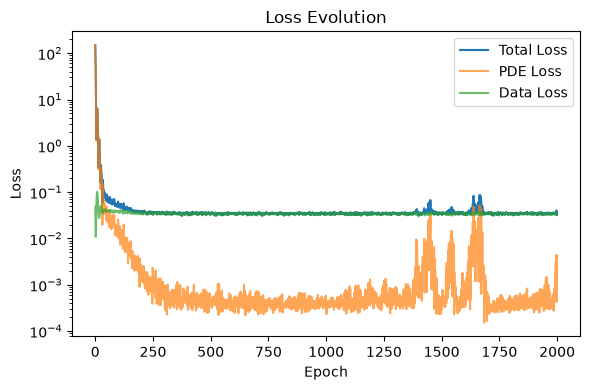

In [32]:
#| code-summary: "Neural Network definition and Training"
from matplotlib import pyplot as plt

class MyNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 16),
            torch.nn.Tanh(),
            torch.nn.Linear(16, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 16),
            torch.nn.Tanh(),
            torch.nn.Linear(16, 4),
            torch.nn.Tanh(),
            torch.nn.Linear(4, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# model
model = MyNN()
model.train()

# training
l1_list, l2_list, loss_list = algorithm_1(model, 0.8, 256, 0.8, 512, 200, 10)

# plot evolution of the losses
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_list, label='Total Loss')
ax.plot(l1_list, label='PDE Loss', alpha=0.7)
ax.plot(l2_list, label='Data Loss', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Evolution')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

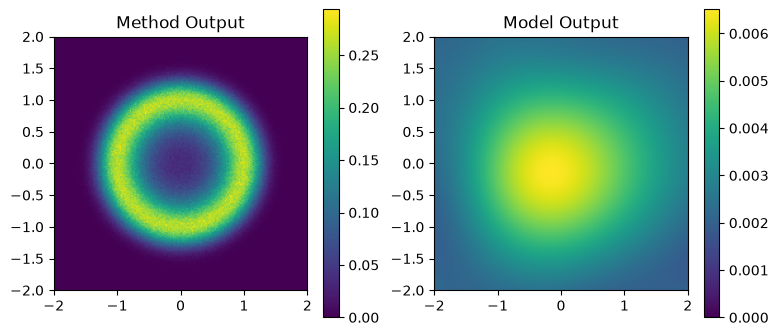

In [33]:
#| code-summary: "Plot the final solution"
# plot the final solution
from matplotlib import pyplot as plt
model.eval()

hx, hy = 200, 200
x = torch.linspace(-r,r,hx)
y = torch.linspace(-r,r,hy)
x,y = torch.meshgrid(x,y, indexing='ij')
xy = torch.stack((x,y), dim=-1)
sol = method(xy.reshape(-1,2)).reshape(hx,hy)
app = model(xy).reshape(hx,hy)

# genero 2 subplot, uno con la soluzione teorica e uno con la soluzione approssimata
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
imsol = ax[0].imshow(
    sol.detach().numpy(),
    cmap='viridis',
    extent=[-r,r,-r,r],
    vmin=0,
    aspect='equal'
)
ax[0].set_title('Method Output')
fig.colorbar(imsol, ax=ax[0])

imapp = ax[1].imshow(
    app.detach().numpy(),
    cmap="viridis",
    extent=[-r, r, -r, r],
    vmin=0,
    aspect="equal"
)
ax[1].set_title('Model Output')

# insert colorbar
fig.colorbar(imapp, ax=ax[1])
plt.show()